# Image Processing Assignment: Baboon

Use the **baboon** image to practice image loading, displaying, resizing, scaling, cropping, grayscale conversion, side-by-side plotting, kernel creation, Gaussian blur, edge detection, unsharp masking, and saving images.

## Notes


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Question 1
Can you load the baboon image with OpenCV or Matplotlib?

In [2]:
# Update this path if the image has a different filename or location.
image_path = 'baboon.png'

img_cv2 = cv2.imread(image_path)
img_mpl = plt.imread(image_path)

print('cv2 shape:', img_cv2.shape)
print('matplotlib shape:', img_mpl.shape)

cv2 shape: (512, 512, 3)
matplotlib shape: (512, 512, 3)


## Function Notes: Image Loading
- `cv2.imread(filename, flags)`: reads an image using OpenCV in BGR order.
- `plt.imread(fname)`: reads an image into a NumPy array for display.

## Function Notes: Basic Display
- `plt.subplots(rows, cols, figsize=(w, h))`: creates multiple axes.
- `ax.imshow(image, cmap=...)`: displays an image on a subplot.
- `ax.set_title('text')`: sets subplot title.
- `ax.axis('off')`: hides axes.

### Question 2
Can you display the baboon image?

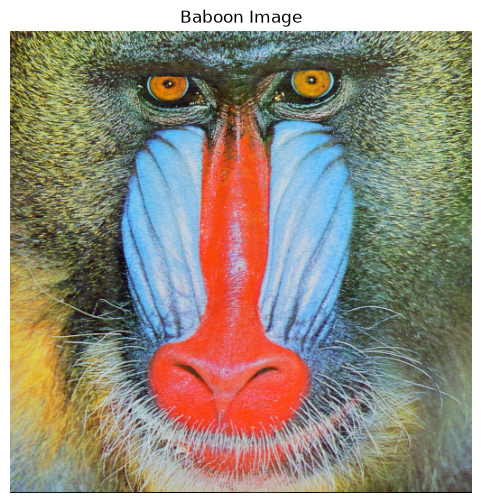

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img_mpl)
plt.title('Baboon Image')
plt.axis('off')
plt.show()

## Function Notes: Geometric Transformations
- `cv2.resize(src, dsize, fx=..., fy=..., interpolation=...)`: resizes an image.

## Function Notes: Subplots and Axes

- plt.subplots: Creates a figure and multiple axes in one call.
  Syntax: `fig, (ax1, ax2, ...) = plt.subplots(rows, cols, figsize=(w, h))`
- Axes.imshow: Displays data on a specific subplot axis.
  Syntax: `ax.imshow(image, cmap=...)`
- Axes.set_title: Sets title for a specific subplot.
  Syntax: `ax.set_title('text')`

### Question 3
- 1) Can you resize down (reduced resolution) by 1/4 and scale up (digital zooming) to the original size of the baboon image?
- 2) Plot the resized and scaled images side by side.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.026011918..1.0116594].


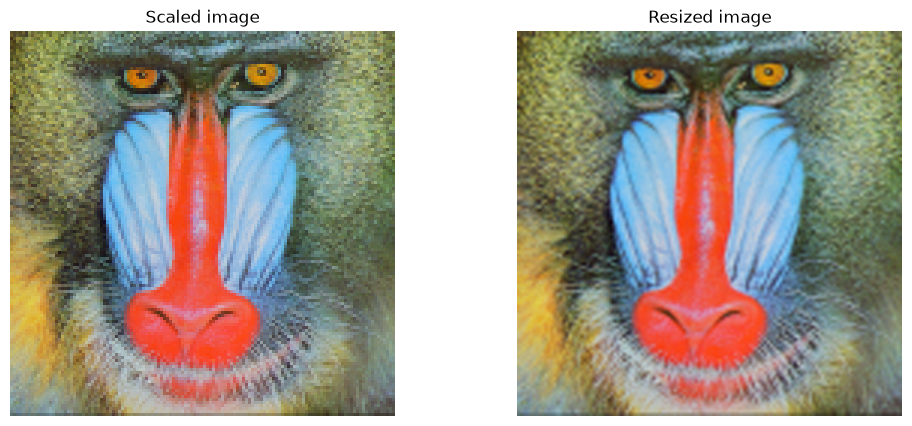

In [7]:
img_scaled = cv2.resize(img_mpl, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
img_resized = cv2.resize(img_scaled, (512, 512), interpolation=cv2.INTER_CUBIC)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_scaled)
ax1.set_title('Scaled image')
ax1.axis('off')

ax2.imshow(img_resized)
ax2.set_title('Resized image')
ax2.axis('off')
plt.show()

## Function Notes: Cropping
- NumPy slicing: `crop = image[y1:y2, x1:x2]`
- `image.shape[:2]`: gets height and width.

### Question 4
Can you crop a center region from the baboon image?

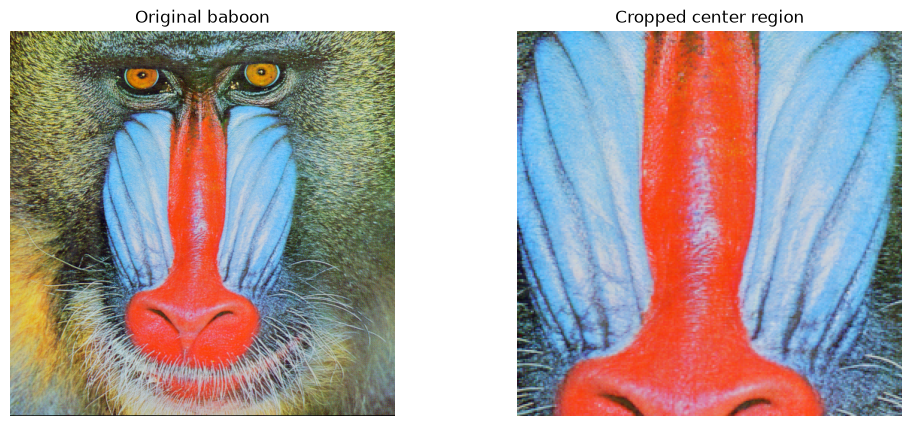

In [9]:
h, w = img_mpl.shape[:2]
y1, y2 = int(h * 0.25), int(h * 0.75)
x1, x2 = int(w * 0.25), int(w * 0.75)
img_crop = img_mpl[y1:y2, x1:x2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_mpl)
ax1.set_title('Original baboon')
ax1.axis('off')

ax2.imshow(img_crop)
ax2.set_title('Cropped center region')
ax2.axis('off')
plt.show()

## Function Notes: Color Conversion
- `cv2.cvtColor(src, code)`: converts between color spaces.
- Example: RGB to grayscale.

### Question 5
Can you convert the baboon image from RGB to grayscale and plot it?

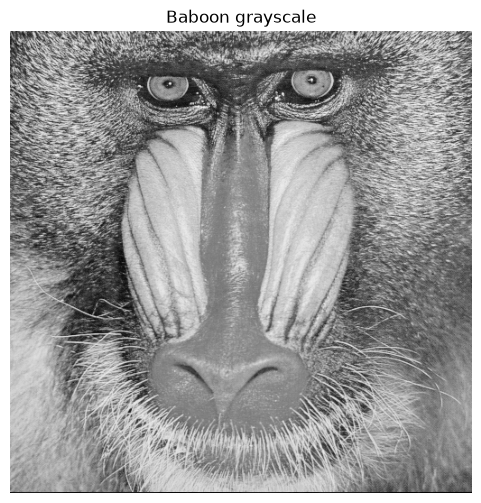

In [11]:
img_gray = cv2.cvtColor(img_mpl, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_gray, cmap='gray')
ax.set_title('Baboon grayscale')
ax.axis('off')
plt.show()

## Function Notes: Kernel Creation
- `np.ones(shape, dtype=...)`: creates an averaging kernel.
- `np.array(...)`: creates a custom kernel.

### Question 6
Can you create a 3×3 blur kernel for the baboon image?
$$ \frac{1}{16}  
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}


In [12]:
kernel_blur = kernel_edge_dectect = np.array([[1, 2, 1],
                           [2,  4, 2],
                           [1, 2, 1]]) / 16.0
print(kernel_blur)

[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]


## Function Notes: Gaussian Smoothing
- `cv2.GaussianBlur(src, ksize, sigmaX)`: applies Gaussian blur.

### Question 7
Can you apply Gaussian blur to the baboon grayscale image?

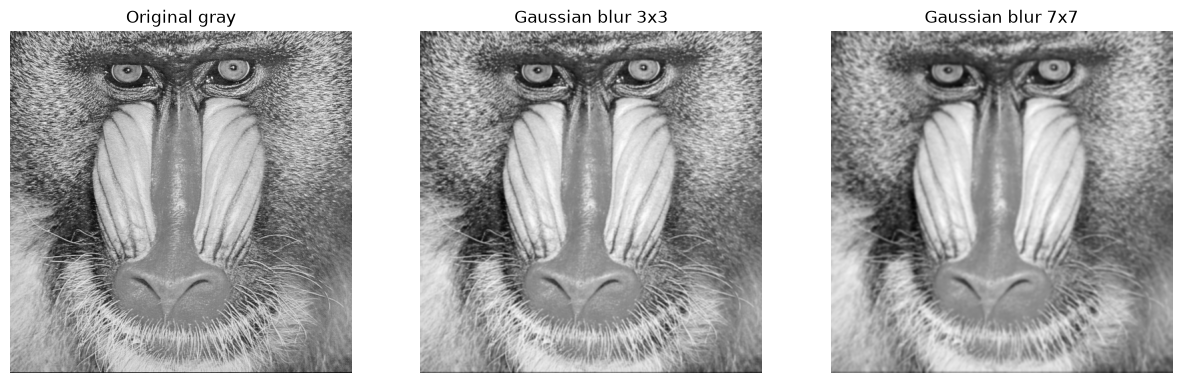

In [13]:
gauss_3 = cv2.GaussianBlur(img_gray, (3, 3), 0)
gauss_7 = cv2.GaussianBlur(img_gray, (7, 7), 0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original gray')
ax1.axis('off')

ax2.imshow(gauss_3, cmap='gray')
ax2.set_title('Gaussian blur 3x3')
ax2.axis('off')

ax3.imshow(gauss_7, cmap='gray')
ax3.set_title('Gaussian blur 7x7')
ax3.axis('off')
plt.show()

## Function Notes: Linear Filtering
- `cv2.filter2D(src, ddepth, kernel)`: applies a custom convolution kernel.

### Question 8
Can you detect edges in the baboon grayscale image with a kernel below?

$$   
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}

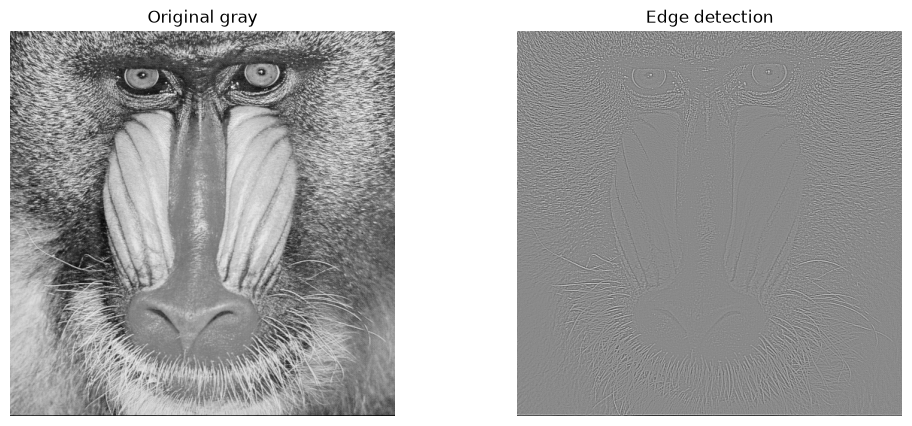

In [14]:
kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

edges = cv2.filter2D(img_gray, -1, kernel_edge)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original gray')
ax1.axis('off')

ax2.imshow(edges, cmap='gray')
ax2.set_title('Edge detection')
ax2.axis('off')
plt.show()

## Function Notes: Weighted Blending
- `cv2.addWeighted(src1, alpha, src2, beta, gamma)`: blends two images.
- Used here for unsharp masking.

### Question 9
Can you sharpen the baboon grayscale image using unsharp masking?

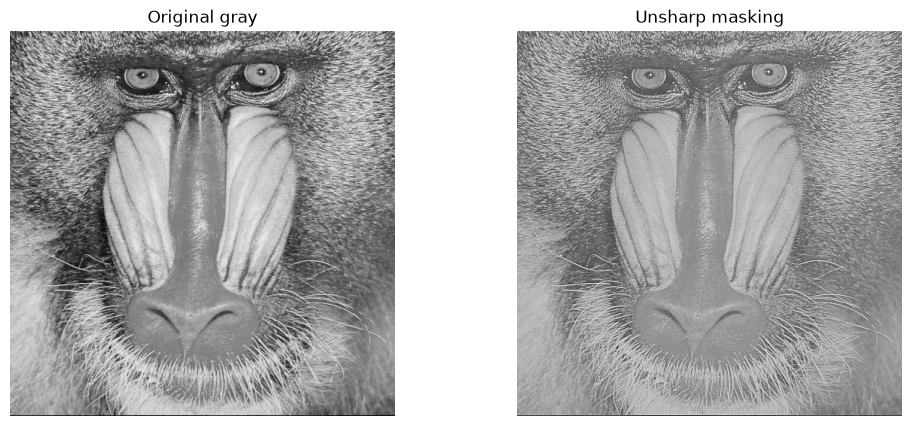

In [15]:
blur_for_sharpen = cv2.GaussianBlur(img_gray, (5, 5), 0)
sharpened = cv2.addWeighted(img_gray, 2.0, blur_for_sharpen, -1.0, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original gray')
ax1.axis('off')

ax2.imshow(sharpened, cmap='gray')
ax2.set_title('Unsharp masking')
ax2.axis('off')
plt.show()

## Function Notes: Saving Images
- `cv2.imwrite(filename, img)`: writes an image to disk.
- `plt.imsave(fname, arr, cmap=...)`: saves an image with matplotlib.

### Question 10
Can you save the processed baboon images (any 1x gray scale and 1x colored) to disk?

In [16]:
cv2.imwrite('baboon_gray.png', img_gray)
cv2.imwrite('baboon_gaussian_7x7.png', gauss_7)
cv2.imwrite('baboon_edges.png', edges)
cv2.imwrite('baboon_sharpened.png', sharpened)

print('Saved: baboon_gray.png, baboon_gaussian_7x7.png, baboon_edges.png, baboon_sharpened.png')

Saved: baboon_gray.png, baboon_gaussian_7x7.png, baboon_edges.png, baboon_sharpened.png
